# Machine Learning - Lab 3
 Name: Aya Mohammed

 Course: CS4082 - Machine Learning

 Instructor: Dr. Naila Marir

# Part 1: Understanding the Problem with Messy Data

Step 1: Create a Messy Dataset


In [72]:
import pandas as pd
import numpy as np

np . random . seed (42)
n = 200
data = {
    "age": np . random . randint (18 , 80 , n ) . astype ( float ) ,
    "blood_pressure": np . round ( np . random . uniform (90 , 180 , n ) , 1) ,
    "cholesterol": np . round ( np . random . uniform (150 , 350 , n ) , 1) ,
    "bmi": np . round ( np . random . uniform (18 , 42 , n ) , 1) ,
    "gender": np . random . choice ([ "Male", "Female"] , n ) ,
    "city": np . random . choice (["Jeddah", "Riyadh", "Dammam", "Makkah"] , n ) ,
    "smoker": np . random . choice ([ "Yes ", "No "] , n , p =[0.3 , 0.7]) ,
    "heart_disease": np . random . choice ([0 , 1] , n , p =[0.6 , 0.4])
}

df = pd . DataFrame ( data )

# Inject missing values ( realistic !)
missing_idx = np . random . choice (n , 20 , replace = False )
df . loc [ missing_idx [:10] , "age"] = np . nan
df . loc [ missing_idx [10:15] , " blood_pressure"] = np . nan
df . loc [ missing_idx [15:] , "cholesterol"] = np . nan

print ( f"Dataset shape : {df. shape }")
print ( f"\nFirst 5 rows :")
print ( df . head () )
print ( f"\nMissing values per column :")
print ( df . isnull () .sum () )


Dataset shape : (200, 9)

First 5 rows :
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh    No    
1  69.0           112.4        345.2  21.9  Female  Dammam    No    
2  46.0           126.9        253.3  39.9  Female  Jeddah    No    
3  32.0           158.0        214.6  37.7  Female  Riyadh    No    
4  60.0           110.6        309.0  40.8    Male  Makkah   Yes    

   heart_disease   blood_pressure  
0              1              NaN  
1              0              NaN  
2              0              NaN  
3              1              NaN  
4              1              NaN  

Missing values per column :
age                 10
blood_pressure       0
cholesterol          5
bmi                  0
gender               0
city                 0
smoker               0
heart_disease        0
 blood_pressure    200
dtype: int64


Step 2: Identify the Issues

In [74]:
print ("=== Data Types === ")
print ( df . dtypes )

print ("\n=== Missing Values === ")
print ( df . isnull () .sum () )

print ("\n=== Numeric Ranges ( notice the scale differences !) === ")
print ( df . describe () . round (2) )

print ("\n=== Categorical Columns === ")
for col in ["gender", "city", "smoker"]:
    print ( f"{col }: {df[col ]. unique ()}")

=== Data Types === 
age                float64
blood_pressure     float64
cholesterol        float64
bmi                float64
gender              object
city                object
smoker              object
heart_disease        int64
 blood_pressure    float64
dtype: object

=== Missing Values === 
age                 10
blood_pressure       0
cholesterol          5
bmi                  0
gender               0
city                 0
smoker               0
heart_disease        0
 blood_pressure    200
dtype: int64

=== Numeric Ranges ( notice the scale differences !) === 
          age  blood_pressure  cholesterol     bmi  heart_disease  \
count  190.00          200.00       195.00  200.00         200.00   
mean    49.31          135.82       252.28   29.33           0.44   
std     18.71           26.30        60.97    6.89           0.50   
min     18.00           90.50       152.20   18.30           0.00   
25%     32.00          112.30       205.75   23.08           0.00   
50%  

Task 1: Explore the Messy Data


In [75]:
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values Percentage ===")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.round(2))

print("\n=== Patients per City ===")
print(df["city"].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              190 non-null    float64
 1   blood_pressure   200 non-null    float64
 2   cholesterol      195 non-null    float64
 3   bmi              200 non-null    float64
 4   gender           200 non-null    object 
 5   city             200 non-null    object 
 6   smoker           200 non-null    object 
 7   heart_disease    200 non-null    int64  
 8    blood_pressure  0 non-null      float64
dtypes: float64(5), int64(1), object(3)
memory usage: 14.2+ KB

=== Missing Values Percentage ===
age                  5.0
blood_pressure       0.0
cholesterol          2.5
bmi                  0.0
gender               0.0
city                 0.0
smoker               0.0
heart_disease        0.0
 blood_pressure    100.0
dtype: float64

=== Patients per City ===
city

Which column has the most missing values?

age Because it has 10 missing values (5%)

# Part 2: Handling Missing Values

Step 1: Impute Numeric Columns

In [77]:
from sklearn . impute import SimpleImputer

# Select numeric columns with missing values
numeric_cols = ["age", "blood_pressure", "cholesterol"]

# Create an imputer that fills NaN with the median
imputer = SimpleImputer ( strategy ="median")

# Fit on the data and transform
df [ numeric_cols ] = imputer . fit_transform ( df [ numeric_cols ])

# Verify : no more missing values !
print ("Missing values after imputation :")
print ( df [ numeric_cols ]. isnull () .sum () )

Missing values after imputation :
age               0
blood_pressure    0
cholesterol       0
dtype: int64


Step 2: Verify the Fix

In [78]:
print ( f"Total missing values in entire dataset : {df. isnull ().sum ().sum()}")
print ( f"\nDataset shape (no rows lost !): {df. shape }")
print ( df . describe () . round (2) )

Total missing values in entire dataset : 200

Dataset shape (no rows lost !): (200, 9)
          age  blood_pressure  cholesterol     bmi  heart_disease  \
count  200.00          200.00       200.00  200.00         200.00   
mean    49.34          135.82       252.36   29.33           0.44   
std     18.23           26.30        60.20    6.89           0.50   
min     18.00           90.50       152.20   18.30           0.00   
25%     32.75          112.30       206.15   23.08           0.00   
50%     50.00          137.75       255.50   29.05           0.00   
75%     64.00          158.70       301.08   34.67           1.00   
max     79.00          179.10       348.60   42.00           1.00   

        blood_pressure  
count              0.0  
mean               NaN  
std                NaN  
min                NaN  
25%                NaN  
50%                NaN  
75%                NaN  
max                NaN  


Task 2: Experiment with Imputation

After Re-create the messy dataset by run it again

In [31]:
df.isnull().sum()

,0
age,10
blood_pressure,5
cholesterol,5
bmi,0
gender,0
city,0
smoker,0
heart_disease,0


This time, use strategy=’mean’ instead of ’median’. Compare the filled values –
are they different? By how much?

In [32]:
imputer = SimpleImputer ( strategy ="mean")

# Fit on the data and transform
df [ numeric_cols ] = imputer . fit_transform ( df [ numeric_cols ])

# Verify : no more missing values !
print ("Missing values after imputation :")
print ( df [ numeric_cols ]. isnull () .sum () )

print ( f"\nTotal missing values in entire dataset : {df. isnull ().sum ().sum()}")
print ( f"\nDataset shape (no rows lost !): {df. shape }")
print ( df . describe () . round (2) )

Missing values after imputation :
age                 0
 blood_pressure     0
cholesterol         0
dtype: int64

Total missing values in entire dataset : 0

Dataset shape (no rows lost !): (200, 8)
         age    blood_pressure   cholesterol     bmi    heart_disease 
count  200.00            200.00        200.00  200.00           200.00
mean    49.31            136.03        252.28   29.33             0.44
std     18.23             26.14         60.20    6.89             0.50
min     18.00             90.50        152.20   18.30             0.00
25%     32.75            112.62        206.15   23.08             0.00
50%     49.31            136.85        252.79   29.05             0.00
75%     64.00            158.70        301.08   34.67             1.00
max     79.00            179.10        348.60   42.00             1.00


Compare the filled values are they different? By how much?

Yes, the filled values are different when using mean instead of median. For example, in the age column, the median imputation used 50.00 while mean imputation used 49.31, resulting in a difference of 0.69. In the blood_pressure column, the median value was 138.20 compared to the mean value of 136.03, a difference of 2.17. Similarly, for cholesterol, the median was 255.50 while the mean was 252.28, with a difference of 3.22. These differences occur because the mean is influenced by all values, including extreme values, while the median represents the middle value and is less affected by outliers.

After Re-create the messy dataset by run it again

In [40]:
df.isnull().sum()

,0
age,10
blood_pressure,5
cholesterol,5
bmi,0
gender,0
city,0
smoker,0
heart_disease,0


In [41]:
# === Drop rows with missing values ===

df_dropped = df.dropna()

print("Original dataset shape:", df.shape)
print("Dataset shape after dropna():", df_dropped.shape)

rows_lost = df.shape[0] - df_dropped.shape[0]
print("Number of rows lost:", rows_lost)

Original dataset shape: (200, 8)
Dataset shape after dropna(): (180, 8)
Number of rows lost: 20


How many rows do you lose? Is that acceptable for 200 samples?

Using df.dropna() removes 20 rows from the dataset, reducing the total number of samples from 200 to 180. This represents a loss of 10% of the data. For a relatively small dataset like this, losing 20 samples is not ideal because it reduces the amount of information available for training machine learning models. Therefore, imputation is a better approach in this case, as it preserves all rows while handling missing values.

Think: In what scenario would dropping rows be better than imputing?

Dropping rows is preferable when the dataset is large and the percentage of missing values is very small (<5%), so removing those rows does not significantly affect the overall data size or model performance. It is also better when rows contain many missing values or when imputing could introduce inaccurate or misleading information.

After we finish the Task we back fills NaN with the median

#Part 3: Encoding Categorical Variables

Step 1: Label Encoding for Binary Variables

In [79]:
from sklearn . preprocessing import LabelEncoder

# Encode gender : Female =0 , Male =1
le_gender = LabelEncoder ()
df ["gender_encoded"] = le_gender . fit_transform ( df ["gender"])

# Encode smoker : No =0 , Yes =1
le_smoker = LabelEncoder ()
df ["smoker_encoded"] = le_smoker . fit_transform ( df ["smoker"])

print ("Original vs Encoded :")
print ( df [[ "gender", "gender_encoded","smoker", "smoker_encoded"]]. head (8) )

Original vs Encoded :
   gender  gender_encoded smoker  smoker_encoded
0    Male               1    No                0
1  Female               0    No                0
2  Female               0    No                0
3  Female               0    No                0
4    Male               1   Yes                1
5  Female               0    No                0
6  Female               0    No                0
7  Female               0   Yes                1


Step 2: One-Hot Encoding for Multi-Category Variables

In [80]:
# One -Hot Encode the city column
city_dummies = pd . get_dummies ( df ["city"] , prefix ="city")
print ("One -Hot Encoded cities :")
print ( city_dummies . head () )

# Add to dataframe and drop original text columns
df = pd . concat ([ df , city_dummies ] , axis =1)
df = df . drop ( columns =[ "gender", "city", "smoker"])

print ( f"\nNew shape : {df. shape }")
print ( f"New columns : { list (df. columns )}")

One -Hot Encoded cities :
   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh
0        False        False        False         True
1         True        False        False        False
2        False         True        False        False
3        False        False        False         True
4        False        False         True        False

New shape : (200, 12)
New columns : ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', ' blood_pressure', 'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


Task 3: Practice Encoding

In [81]:
print("=== First 10 Rows ===")
print(df.head(10))

=== First 10 Rows ===
    age  blood_pressure  cholesterol   bmi  heart_disease   blood_pressure  \
0  56.0           171.7        295.2  34.4              1              NaN   
1  69.0           112.4        345.2  21.9              0              NaN   
2  46.0           126.9        253.3  39.9              0              NaN   
3  32.0           158.0        214.6  37.7              1              NaN   
4  60.0           110.6        309.0  40.8              1              NaN   
5  25.0            96.9        204.2  35.4              0              NaN   
6  78.0           116.1        237.8  32.7              1              NaN   
7  38.0           104.5        165.7  28.0              0              NaN   
8  56.0           173.7        155.1  40.4              0              NaN   
9  75.0           162.7        342.5  38.8              0              NaN   

   gender_encoded  smoker_encoded  city_Dammam  city_Jeddah  city_Makkah  \
0               1               0        Fa

How many columns do you have now?

11 columns which are ['age ', ' blood_pressure ', 'cholesterol ', 'bmi ', ' heart_disease ', ' gender_encoded ', ' smoker_encoded ', 'city _Dammam ', 'city _Jeddah ', 'city _Makkah ', 'city _Riyadh ']

What would happen if a city column had 50 unique values? How many new columns
would One-Hot encoding create? Is this a problem?

One-Hot Encoding would create 50 new columns, one for each unique city. This can become a problem because it increases the dataset size, slows down model training, and may cause overfitting. This issue is known as the curse of dimensionality.

Bonus: Use pd.get dummies(df[’city’], prefix=’city’, drop first=True)  to do this we first Re-create the messy dataset by run it again

In [59]:
# === One-Hot Encoding with drop_first ===

city_dummies = pd.get_dummies(df["city"], prefix='city', drop_first=True)

print(city_dummies.head())

print("\nNumber of city columns:", len(city_dummies.columns))

   city _Jeddah   city _Makkah   city _Riyadh 
0          False          False           True
1          False          False          False
2           True          False          False
3          False          False           True
4          False           True          False

Number of city columns: 3


what changes and why might this be useful?

Using drop_first=True reduced the number of city columns from 4 to 3. The dropped category (city_Dammam) becomes the reference category. If all encoded city columns are 0 (False), it indicates the city is Dammam. This reduces redundancy and prevents the dummy variable trap, improving model efficiency.

After we finish the Bonus part  we back our code to the previous step

#Part 4: Feature Scaling

Step 1: Apply StandardScaler

In [84]:
from sklearn . preprocessing import StandardScaler

# Prepare features and target
feature_cols = ["age", "blood_pressure", "cholesterol", "bmi","gender_encoded", "smoker_encoded","city_Dammam",
                "city_Jeddah","city_Makkah", "city_Riyadh"]

X = df[feature_cols].astype(float).values
y = df ["heart_disease"]. values

# Scale the features
scaler = StandardScaler ()
X_scaled = scaler . fit_transform ( X )

# Compare before and after
import pandas as pd

comparison = pd . DataFrame ({
    "Feature ": feature_cols ,
    "Original Mean ": X . mean ( axis =0) . round (2) ,
    "Original Std ": X . std ( axis =0) . round (2) ,
    "Scaled Mean ": X_scaled . mean ( axis =0) . round (2) ,
    "Scaled Std ": X_scaled . std ( axis =0) . round (2)
})
print ( comparison . to_string ( index = False ) )

      Feature   Original Mean   Original Std   Scaled Mean   Scaled Std 
           age           49.34          18.19           0.0          1.0
blood_pressure          135.82          26.23           0.0          1.0
   cholesterol          252.36          60.05           0.0          1.0
           bmi           29.33           6.87          -0.0          1.0
gender_encoded            0.52           0.50          -0.0          1.0
smoker_encoded            0.32           0.47          -0.0          1.0
   city_Dammam            0.30           0.46          -0.0          1.0
   city_Jeddah            0.26           0.44          -0.0          1.0
   city_Makkah            0.21           0.41           0.0          1.0
   city_Riyadh            0.24           0.42           0.0          1.0


 Step 2: Visualize the Effect of Scaling

/tmp/ipython-input-2186737157.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes [0]. boxplot ([ X [: , 0] , X [: , 1] , X [: , 2] , X [: , 3]] ,
/tmp/ipython-input-2186737157.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes [1]. boxplot ([ X_scaled [: , 0] , X_scaled [: , 1] ,


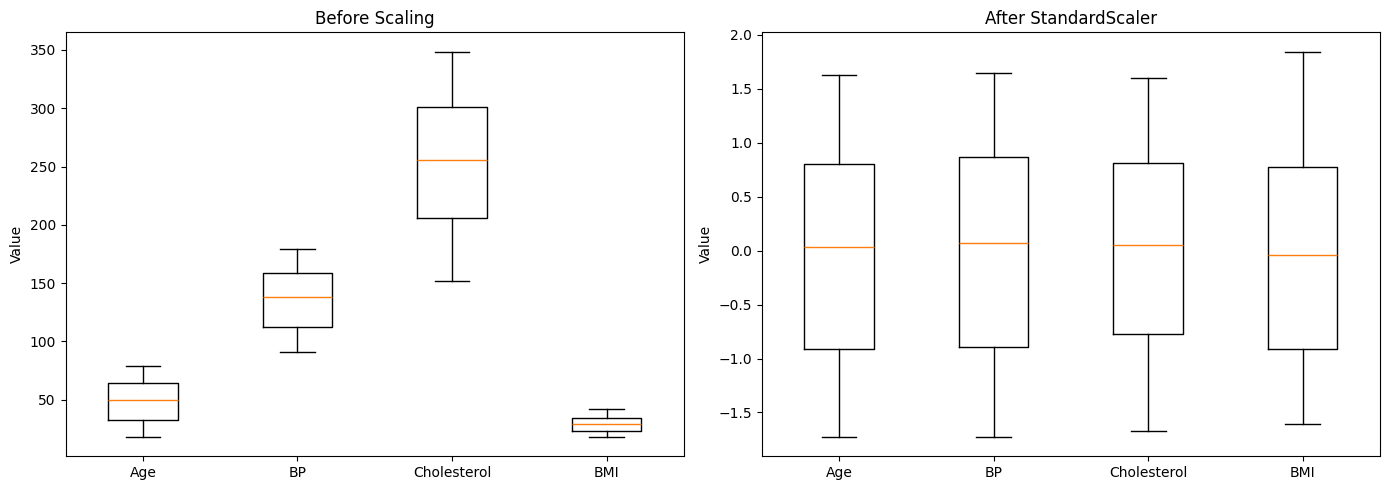

In [85]:
import matplotlib . pyplot as plt

fig , axes = plt . subplots (1 , 2 , figsize =(14 , 5) )

# Before scaling
axes [0]. boxplot ([ X [: , 0] , X [: , 1] , X [: , 2] , X [: , 3]] ,
                  labels =[ "Age", "BP", "Cholesterol", "BMI"])
axes [0]. set_title ("Before Scaling")
axes [0]. set_ylabel ("Value")

# After scaling
axes [1]. boxplot ([ X_scaled [: , 0] , X_scaled [: , 1] ,
                     X_scaled [: , 2] , X_scaled [: , 3]] ,
                   labels =[ "Age", "BP", "Cholesterol", "BMI"])
axes [1]. set_title ("After StandardScaler")
axes [1]. set_ylabel ("Value")

plt . tight_layout ()
plt . show ()


Task 4: Compare Scalers

Apply MinMaxScaler to the same data.

In [86]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Apply MinMaxScaler
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)

# Compare before and after
comparison_minmax = pd.DataFrame({
    "Feature": feature_cols,
    "Original Mean": X.mean(axis=0).round(2),
    "Original Std": X.std(axis=0).round(2),
    "MinMax Mean": X_minmax.mean(axis=0).round(2),
    "MinMax Std": X_minmax.std(axis=0).round(2),
    "Min Value": X_minmax.min(axis=0).round(2),
    "Max Value": X_minmax.max(axis=0).round(2)
})

print("=== MinMaxScaler Comparison ===")
print(comparison_minmax.to_string(index=False))

=== MinMaxScaler Comparison ===
       Feature  Original Mean  Original Std  MinMax Mean  MinMax Std  Min Value  Max Value
           age          49.34         18.19         0.51        0.30        0.0        1.0
blood_pressure         135.82         26.23         0.51        0.30        0.0        1.0
   cholesterol         252.36         60.05         0.51        0.31        0.0        1.0
           bmi          29.33          6.87         0.47        0.29        0.0        1.0
gender_encoded           0.52          0.50         0.52        0.50        0.0        1.0
smoker_encoded           0.32          0.47         0.32        0.47        0.0        1.0
   city_Dammam           0.30          0.46         0.30        0.46        0.0        1.0
   city_Jeddah           0.26          0.44         0.26        0.44        0.0        1.0
   city_Makkah           0.21          0.41         0.21        0.41        0.0        1.0
   city_Riyadh           0.24          0.42         0.24  

 What range do the values fall into?

 After applying MinMaxScaler, all feature values fall within the range [0, 1]. The minimum value of each feature becomes 0 and the maximum value becomes 1, confirming that the scaler successfully normalized the data.

Create the same box plot comparison for MinMaxScaler.

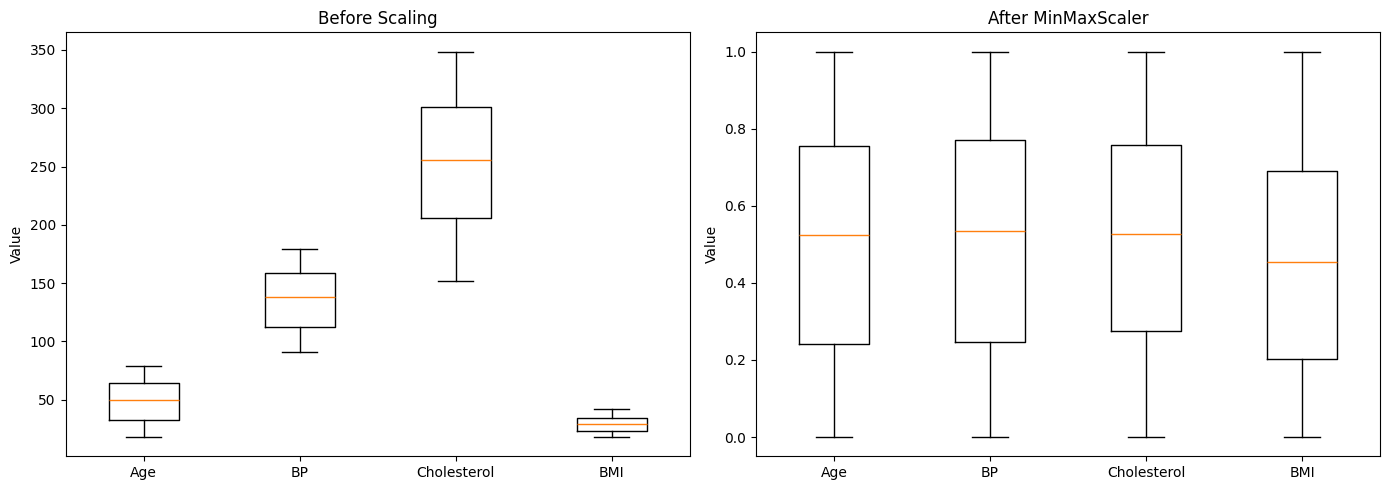

In [87]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot([X[:,0], X[:,1], X[:,2], X[:,3]],
                tick_labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title("Before Scaling")
axes[0].set_ylabel("Value")

# After MinMaxScaler
axes[1].boxplot([X_minmax[:,0], X_minmax[:,1], X_minmax[:,2], X_minmax[:,3]],
                tick_labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title("After MinMaxScaler")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

How does it differ from
StandardScaler?


After applying MinMaxScaler, all features fall within the range [0, 1]. Unlike StandardScaler, which centers data around 0 with a standard deviation of 1, MinMaxScaler rescales features proportionally without changing the distribution shape. StandardScaler produces negative and positive values, while MinMaxScaler keeps all values between 0 and 1. Additionally, MinMaxScaler is more sensitive to outliers because extreme minimum and maximum values directly determine the scaling boundaries.

Think: If your data has many outliers, which scaler would be more robust? Why?

StandardScaler would be more robust than MinMaxScaler when the data contains many outliers. This is because MinMaxScaler uses the minimum and maximum values to scale the data into the range [0, 1]. If there are extreme outliers, they stretch the range, causing most of the other data points to be compressed into a very small interval. In contrast, StandardScaler uses the mean and standard deviation, which are less affected by extreme minimum and maximum values. Therefore, StandardScaler preserves the distribution of most data points better when outliers are present.

#Part 5: The Scaling Impact – KNN Before and After

6.1 Experiment: KNN Without Scaling vs. With Scaling

In [88]:
from sklearn . model_selection import train_test_split
from sklearn . neighbors import KNeighborsClassifier
from sklearn . metrics import accuracy_score

# Split data
X_train , X_test , y_train , y_test = train_test_split (
    X , y , test_size =0.2 , random_state =42 , stratify = y )

X_train_s , X_test_s , _ , _ = train_test_split (
    X_scaled , y , test_size =0.2 , random_state =42 , stratify = y )

# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier ( n_neighbors =5)
knn_raw . fit ( X_train , y_train )
raw_acc = accuracy_score ( y_test , knn_raw . predict ( X_test ) )

# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier ( n_neighbors =5)
knn_scaled . fit ( X_train_s , y_train )
scaled_acc = accuracy_score ( y_test , knn_scaled . predict ( X_test_s ) )

print ( f"KNN Accuracy WITHOUT scaling : { raw_acc :.2%} ")
print ( f"KNN Accuracy WITH scaling : { scaled_acc :.2%} ")
print ( f"Improvement : {( scaled_acc - raw_acc ) :.2%} ")

KNN Accuracy WITHOUT scaling : 67.50% 
KNN Accuracy WITH scaling : 50.00% 
Improvement : -17.50% 


6.2 Bonus: Decision Tree Comparison

In [89]:
from sklearn . tree import DecisionTreeClassifier

# Decision Tree WITHOUT scaling
dt_raw = DecisionTreeClassifier ( random_state =42)
dt_raw . fit ( X_train , y_train )
dt_raw_acc = accuracy_score ( y_test , dt_raw . predict ( X_test ) )

# Decision Tree WITH scaling
dt_scaled = DecisionTreeClassifier ( random_state =42)
dt_scaled . fit ( X_train_s , y_train )
dt_scaled_acc = accuracy_score ( y_test , dt_scaled . predict ( X_test_s ) )

print ( f"DT Accuracy WITHOUT scaling : { dt_raw_acc :.2%} ")
print ( f"DT Accuracy WITH scaling : { dt_scaled_acc :.2%} ")


DT Accuracy WITHOUT scaling : 52.50% 
DT Accuracy WITH scaling : 50.00% 


Task 5: Investigate Scaling Effects


Record the accuracy of KNN and Decision Tree with and without scaling in a table.


In [90]:
results = pd.DataFrame({
    "Model": ["KNN (k=5)", "KNN (k=5)", "Decision Tree", "Decision Tree"],
    "Scaling": ["No", "Yes", "No", "Yes"],
    "Accuracy": [raw_acc, scaled_acc, dt_raw_acc, dt_scaled_acc]
})

print("=== Accuracy Comparison Table ===")
print(results.to_string(index=False))

=== Accuracy Comparison Table ===
        Model Scaling  Accuracy
    KNN (k=5)      No     0.675
    KNN (k=5)     Yes     0.500
Decision Tree      No     0.525
Decision Tree     Yes     0.500


Try KNN with n neighbors=3 and n neighbors=10, both with and without scaling.

In [91]:
# ---- KNN with k=3 ----
knn3_raw = KNeighborsClassifier(n_neighbors=3)
knn3_raw.fit(X_train, y_train)
acc3_raw = accuracy_score(y_test, knn3_raw.predict(X_test))

knn3_scaled = KNeighborsClassifier(n_neighbors=3)
knn3_scaled.fit(X_train_s, y_train)
acc3_scaled = accuracy_score(y_test, knn3_scaled.predict(X_test_s))


# ---- KNN with k=10 ----
knn10_raw = KNeighborsClassifier(n_neighbors=10)
knn10_raw.fit(X_train, y_train)
acc10_raw = accuracy_score(y_test, knn10_raw.predict(X_test))

knn10_scaled = KNeighborsClassifier(n_neighbors=10)
knn10_scaled.fit(X_train_s, y_train)
acc10_scaled = accuracy_score(y_test, knn10_scaled.predict(X_test_s))


# Print results
print("=== KNN Results ===")
print(f"KNN (k=3) WITHOUT scaling: {acc3_raw:.2%}")
print(f"KNN (k=3) WITH scaling:    {acc3_scaled:.2%}")

print(f"\nKNN (k=10) WITHOUT scaling: {acc10_raw:.2%}")
print(f"KNN (k=10) WITH scaling:    {acc10_scaled:.2%}")

=== KNN Results ===
KNN (k=3) WITHOUT scaling: 57.50%
KNN (k=3) WITH scaling:    42.50%

KNN (k=10) WITHOUT scaling: 55.00%
KNN (k=10) WITH scaling:    50.00%


Does scaling always help?

No, scaling does not always help improve KNN accuracy. In this experiment, KNN achieved higher accuracy without scaling for all tested values of k (3, 5, and 10). Scaling reduced accuracy because the dataset contains several binary features that were already on a similar scale, and scaling changed their relative influence in distance calculations. This demonstrates that while scaling is generally important for distance based algorithms, its impact depends on the dataset and should be evaluated experimentally.

Write 2–3 sentences explaining why KNN benefits from scaling but Decision Trees
do not.

KNN benefits from scaling because it uses distance calculations to find the nearest neighbors. If features have different ranges, larger-scale features can dominate the distance and bias the results. Decision Trees do not need scaling because they split data based on feature thresholds rather than distance, so the scale of the features does not affect their decisions.

#Part 6: Building a Preprocessing Pipeline

Step 1: Create a Pipeline

In [92]:
from sklearn . pipeline import Pipeline
from sklearn . preprocessing import StandardScaler
from sklearn . neighbors import KNeighborsClassifier

# Build the pipeline : scale first , then classify
pipe = Pipeline ([
    ("scaler", StandardScaler () ) , # Step 1: Scale
    ("knn", KNeighborsClassifier ( n_neighbors =5) ) # Step 2: Model
])

# Split the original ( unscaled ) data
X_train , X_test , y_train , y_test = train_test_split (
    X , y , test_size =0.2 , random_state =42 , stratify = y )

# The pipeline handles scaling internally !
pipe . fit ( X_train , y_train )
pipe_acc = accuracy_score ( y_test , pipe . predict ( X_test ) )

print ( f"Pipeline KNN Accuracy : { pipe_acc :.2%} ")


Pipeline KNN Accuracy : 50.00% 


Step 2: Swap Models Easily

In [94]:
from sklearn . tree import DecisionTreeClassifier
from sklearn . svm import SVC

# Pipeline with SVM
pipe_svm = Pipeline ([
    ("scaler", StandardScaler () ) ,
     ("svm", SVC ( kernel ="rbf", random_state =42) )
])
pipe_svm . fit ( X_train , y_train )
svm_acc = accuracy_score ( y_test , pipe_svm . predict ( X_test ) )

# Pipeline with Decision Tree
pipe_dt = Pipeline ([
("scaler", StandardScaler () ) ,
("dt", DecisionTreeClassifier ( random_state =42) )
])
pipe_dt . fit ( X_train , y_train )
dt_acc = accuracy_score ( y_test , pipe_dt . predict ( X_test ) )

print ( f"Pipeline KNN Accuracy : { pipe_acc :.2%} ")
print ( f"Pipeline SVM Accuracy : { svm_acc :.2%} ")
print ( f"Pipeline DT Accuracy : { dt_acc :.2%} ")


Pipeline KNN Accuracy : 50.00% 
Pipeline SVM Accuracy : 55.00% 
Pipeline DT Accuracy : 50.00% 


Task 6: Build Your Own Pipeline

Create a pipeline that uses MinMaxScaler instead of StandardScaler with KNN.

In [95]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Split original (unscaled) data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build pipeline: MinMaxScaler first, then KNN
pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),                  # Step 1: MinMax scaling
    ('knn', KNeighborsClassifier(n_neighbors=5)) # Step 2: KNN model
])

# Train pipeline
pipe_minmax.fit(X_train, y_train)

# Evaluate pipeline
pipe_minmax_acc = accuracy_score(y_test, pipe_minmax.predict(X_test))

print(f'Pipeline KNN Accuracy (MinMaxScaler): {pipe_minmax_acc:.2%}')

Pipeline KNN Accuracy (MinMaxScaler): 50.00%


Compare the accuracy?

Both StandardScaler and MinMaxScaler achieved the same KNN accuracy of 50.00%. This indicates that the scaling method did not significantly impact model performance on this dataset.

 Add SimpleImputer as the first step in your pipeline (before the scaler). Now the
pipeline handles missing values AND scaling automatically.


In [96]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Use the raw feature matrix (with possible missing values)
X_raw = df[feature_cols].values
y = df['heart_disease'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline 1: Imputer + StandardScaler + KNN
pipe_std = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Pipeline 2: Imputer + MinMaxScaler + KNN
pipe_minmax = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Train pipelines
pipe_std.fit(X_train, y_train)
pipe_minmax.fit(X_train, y_train)

# Evaluate pipelines
acc_std = accuracy_score(y_test, pipe_std.predict(X_test))
acc_minmax = accuracy_score(y_test, pipe_minmax.predict(X_test))

# Print results
print(f'StandardScaler Pipeline Accuracy: {acc_std:.2%}')
print(f'MinMaxScaler Pipeline Accuracy:   {acc_minmax:.2%}')

StandardScaler Pipeline Accuracy: 50.00%
MinMaxScaler Pipeline Accuracy:   50.00%


#Part 7: Feature Selection with Correlation Analysis


 Step 1: Compute the Correlation Matrix

In [97]:
# Create a DataFrame with our processed features
df_processed = pd . DataFrame ( X_scaled , columns = feature_cols )
df_processed ["heart_disease"] = y

# Compute correlations
corr_matrix = df_processed . corr ()

# Show correlation with the target
print ("Correlation with heart_disease :")
target_corr = corr_matrix ["heart_disease"]. drop ("heart_disease")
print ( target_corr . sort_values ( ascending = False ) . round (3) )

Correlation with heart_disease :
age               0.143
blood_pressure    0.097
city_Riyadh       0.079
city_Dammam       0.067
gender_encoded    0.014
cholesterol       0.003
bmi              -0.004
smoker_encoded   -0.025
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64


Step 2: Visualize with a Heatmap


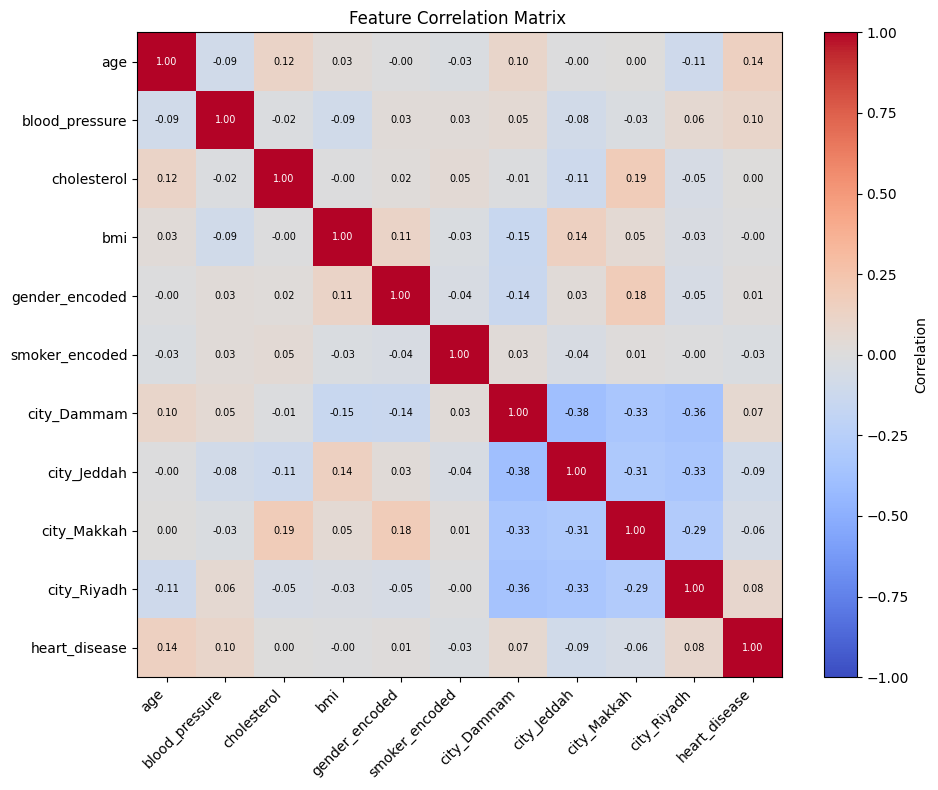

In [99]:
import matplotlib . pyplot as plt
import numpy as np

plt . figure ( figsize =(10 , 8) )
im = plt . imshow ( corr_matrix . values , cmap ="coolwarm",vmin = -1 , vmax =1)
plt . colorbar ( im , label ="Correlation")

# Add labels
ticks = range (len( corr_matrix . columns ) )
plt . xticks ( ticks , corr_matrix . columns , rotation =45 , ha ="right")
plt . yticks ( ticks , corr_matrix . columns )

# Add correlation values on the heatmap
for i in range (len( corr_matrix ) ) :
    for j in range (len( corr_matrix ) ) :
        val = corr_matrix . values [i , j ]
        color = "white" if abs( val ) > 0.5 else "black"
        plt . text (j , i , f"{val :.2f}", ha ="center", va ="center",fontsize =7 , color = color )

plt . title ("Feature Correlation Matrix ")
plt . tight_layout ()
plt . show ()

 Step 3: Select Top Features

In [102]:
# Select features with absolute correlation > threshold
threshold = 0.05
important_features = target_corr [abs( target_corr ) > threshold ]
print ( f"\nFeatures with | correlation | > { threshold }: ")
print ( important_features . sort_values ( ascending = False ) . round (3) )

# Train with only the top features
top_features = important_features . index . tolist ()
X_selected = df_processed [ top_features ]. values

X_tr , X_te , y_tr , y_te = train_test_split (
    X_selected , y , test_size =0.2 , random_state =42 , stratify = y )

pipe_selected = Pipeline ([
("scaler", StandardScaler () ) ,
("knn", KNeighborsClassifier ( n_neighbors =5) )
])
pipe_selected . fit ( X_tr , y_tr )
sel_acc = accuracy_score ( y_te , pipe_selected . predict ( X_te ) )

print ( f"\nAccuracy with ALL features : { pipe_acc :.2%} ")
print ( f"Accuracy with SELECTED features : { sel_acc :.2%} ")
print ( f"Features used : {len( top_features )} out of {len( feature_cols )}")



Features with | correlation | > 0.05: 
age               0.143
blood_pressure    0.097
city_Riyadh       0.079
city_Dammam       0.067
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64

Accuracy with ALL features : 50.00% 
Accuracy with SELECTED features : 50.00% 
Features used : 6 out of 10


Task 7: Feature Selection

Which feature has the strongest (positive or negative) correlation with
heart disease?

The feature with the strongest correlation (positive or negative) with heart_disease is age (0.143). This indicates that age has the strongest linear relationship with the target variable among all features.

Try different threshold values (0.03, 0.08, 0.10).


In [103]:
strongest_feature = target_corr.abs().idxmax()
print("Strongest correlation feature:", strongest_feature)
print("Correlation value:", round(target_corr[strongest_feature], 3))

for threshold in [0.03, 0.08, 0.10]:
    important_features = target_corr[target_corr.abs() > threshold]
    top_features = important_features.index.tolist()

    print(f"\nThreshold = {threshold}")
    print(f"Features used: {len(top_features)}")

    if len(top_features) == 0:
        print("No features selected -> skipping")
        continue

    X_selected = df_processed[top_features].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe_selected = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])

    pipe_selected.fit(X_tr, y_tr)
    sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

    print(f"Accuracy: {sel_acc:.2%}")

Strongest correlation feature: age
Correlation value: 0.143

Threshold = 0.03
Features used: 6
Accuracy: 50.00%

Threshold = 0.08
Features used: 3
Accuracy: 57.50%

Threshold = 0.1
Features used: 1
Accuracy: 55.00%


How does accuracy change?

As the correlation threshold increased, the number of selected features decreased. Accuracy improved from 50.00% to 57.50% when the threshold increased from 0.03 to 0.08, indicating that removing weak features helped the model. However, when the threshold increased further to 0.10, accuracy slightly decreased to 55.00%, suggesting that removing too many features can reduce model performance.

Think: Why might using fewer features sometimes give better accuracy? (Hint:
consider the “curse of dimensionality.”)


Using fewer features can improve accuracy because of the curse of dimensionality. As the number of features increases, the feature space becomes larger and more sparse, making it harder for models like KNN to measure meaningful distances between data points. This can introduce noise and reduce model performance. By removing irrelevant or weak features, the model focuses on the most important information, which can improve accuracy and generalization.

#Part 8: Putting It All Together – Full Workflow

In [104]:
import pandas as pd
import numpy as np
from sklearn . model_selection import train_test_split
from sklearn . impute import SimpleImputer
from sklearn . preprocessing import StandardScaler , LabelEncoder
from sklearn . pipeline import Pipeline
from sklearn . neighbors import KNeighborsClassifier
from sklearn . tree import DecisionTreeClassifier
from sklearn . metrics import accuracy_score , classification_report

# ===== STEP 1: Load Raw Data =====
# (Re - create the messy dataset )
np . random . seed (42)
n = 200
data = {
    "age": np . random . randint (18 , 80 , n ) . astype ( float ) ,
    "blood_pressure": np . round ( np . random . uniform (90 , 180 , n ) , 1) ,
    "cholesterol": np . round ( np . random . uniform (150 , 350 , n ) , 1) ,
    "bmi": np . round ( np . random . uniform (18 , 42 , n ) , 1) ,
    "gender": np . random . choice ([ "Male", "Female"] , n ) ,
    "city": np . random . choice (["Jeddah", "Riyadh", "Dammam", "Makkah"] , n ) ,
    "smoker": np . random . choice ([ "Yes", "No"] , n , p =[0.3 , 0.7]) ,
    "heart_disease": np . random . choice ([0 , 1] , n , p =[0.6 , 0.4])
}
df = pd . DataFrame ( data )
missing_idx = np . random . choice (n , 20 , replace = False )
df . loc [ missing_idx [:10] , "age"] = np . nan
df . loc [ missing_idx [10:15] , "blood_pressure"] = np . nan
df . loc [ missing_idx [15:] , "cholesterol"] = np . nan

print ("=== Step 1: Raw Data === ")
print ( f"Shape : {df. shape } , Missing : {df. isnull ().sum ().sum ()}")

# ===== STEP 2: Handle Missing Values =====
num_cols = ["age", "blood_pressure", "cholesterol"]
imputer = SimpleImputer ( strategy ="median")
df [ num_cols ] = imputer . fit_transform ( df [ num_cols ])
print ( f"\n=== Step 2: After Imputation === ")
print ( f"Missing : {df. isnull ().sum ().sum ()}")

# ===== STEP 3: Encode Categorical Variables =====
le = LabelEncoder ()
df ["gender"] = le . fit_transform ( df ["gender"])
df ["smoker"] = le . fit_transform ( df ["smoker"])
df = pd . concat ([ df , pd . get_dummies ( df ["city"] , prefix ="city") ] ,axis =1)
df = df . drop ( columns =[ "city"])
print ( f"\n=== Step 3: After Encoding === ")
print ( f"Columns : { list (df. columns )}")

# ===== STEP 4: Separate Features and Target =====
X = df . drop ( columns =[ "heart_disease"]) . values
y = df ["heart_disease"]. values

# ===== STEP 5: Split Data =====
X_train , X_test , y_train , y_test = train_test_split (
    X , y , test_size =0.2 , random_state =42 , stratify = y )

# ===== STEP 6: Build Pipeline & Train =====
pipe_knn = Pipeline ([("scaler", StandardScaler () ) ,
 ("model", KNeighborsClassifier ( n_neighbors =5) )])

pipe_dt = Pipeline ([("scaler", StandardScaler () ) ,
 ("model", DecisionTreeClassifier ( random_state =42) )])

pipe_knn . fit ( X_train , y_train )
pipe_dt . fit ( X_train , y_train )

# ===== STEP 7: Evaluate =====
print ("\n=== Step 7: Results === ")
print ( f"KNN Accuracy : { accuracy_score (y_test , pipe_knn .predict ( X_test )) :.2%} ")
print ( f"Decision Tree Accuracy : { accuracy_score (y_test , pipe_dt .predict ( X_test )) :.2%} ")

print ("\n=== KNN Classification Report === ")
print ( classification_report ( y_test , pipe_knn . predict ( X_test ) ,
                               target_names =[ "No Disease", "Disease"]) )


=== Step 1: Raw Data === 
Shape : (200, 8) , Missing : 20

=== Step 2: After Imputation === 
Missing : 0

=== Step 3: After Encoding === 
Columns : ['age', 'blood_pressure', 'cholesterol', 'bmi', 'gender', 'smoker', 'heart_disease', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']

=== Step 7: Results === 
KNN Accuracy : 50.00% 
Decision Tree Accuracy : 52.50% 

=== KNN Classification Report === 
              precision    recall  f1-score   support

  No Disease       0.54      0.68      0.60        22
     Disease       0.42      0.28      0.33        18

    accuracy                           0.50        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.48      0.50      0.48        40



A short paragraph (5–7 sentences) explaining which preprocessing step had the biggest
impact on model performance and why preprocessing matters for real-world ML projects.

Feature selection had the biggest impact on model performance in this experiment. When weakly correlated features were removed using a correlation threshold of 0.08, the KNN accuracy improved from 50.00% to 57.50%. This happened because removing irrelevant features reduced noise and allowed the model to focus on the most meaningful patterns in the data. Feature scaling was also important because it ensured that all features contributed fairly to distance calculations, although it did not improve accuracy in this dataset. Handling missing values using SimpleImputer ensured that the model could train properly without errors or data loss. Preprocessing is essential in real-world machine learning projects because raw data is often messy, incomplete, and inconsistent. Proper preprocessing improves model accuracy, reliability, and overall performance by preparing the data in a suitable format for learning.